# Spotify Personal Listening Analysis

### Overview

The goal of this project is to discover key insights from my own personal listening trends on Spotify over the years. The analysis allows us to track my top artists, songs, and overall listening minutes based on genre, artist, day, month, and year. Also, this analysis tracks the number of skipped artists and which platform I listen on the most.

### Data Understanding

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("/Users/austining/Desktop/spotify_listening_analysis/spotify_json_backup/spotify_cleaned.csv")

In [3]:
print(df.head())
print(df.tail())

   year  month  day day_of_week  hour        date hour_12h  \
0  2017      2   11    Saturday     3  2017-02-11     3 AM   
1  2017      2   11    Saturday     3  2017-02-11     3 AM   
2  2017      2   11    Saturday     3  2017-02-11     3 AM   
3  2017      2   11    Saturday     3  2017-02-11     3 AM   
4  2017      2   11    Saturday     3  2017-02-11     3 AM   

               platform  minutes_played country  ...  \
0  iOS 10.1.1 (iPad5,1)        0.000000      US  ...   
1  iOS 10.1.1 (iPad5,1)        0.297600      US  ...   
2  iOS 10.1.1 (iPad5,1)        0.083967      US  ...   
3  iOS 10.1.1 (iPad5,1)        0.959367      US  ...   
4  iOS 10.1.1 (iPad5,1)        0.009667      US  ...   

                              track_uri start_reason end_reason shuffle  \
0  spotify:track:5x2eUo13k0NTESzkkfy393      playbtn    endplay    True   
1  spotify:track:49gpSgVQTDB6Knvfnccq8y     clickrow    endplay    True   
2  spotify:track:6vaFYx5nXqZGesBPnp6okL     clickrow    endplay  

In [4]:
df.shape

(156209, 23)

In [5]:
df.columns

Index(['year', 'month', 'day', 'day_of_week', 'hour', 'date', 'hour_12h',
       'platform', 'minutes_played', 'country', 'track_name', 'artist_name',
       'album_name', 'track_uri', 'start_reason', 'end_reason', 'shuffle',
       'skipped', 'offline', 'incognito_mode', 'offline_datetime',
       'offline_hour', 'offline_day'],
      dtype='object')

In [6]:
df.dtypes

year                  int64
month                 int64
day                   int64
day_of_week          object
hour                  int64
date                 object
hour_12h             object
platform             object
minutes_played      float64
country              object
track_name           object
artist_name          object
album_name           object
track_uri            object
start_reason         object
end_reason           object
shuffle                bool
skipped                bool
offline                bool
incognito_mode         bool
offline_datetime     object
offline_hour        float64
offline_day          object
dtype: object

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 156209 entries, 0 to 156208
Data columns (total 23 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   year              156209 non-null  int64  
 1   month             156209 non-null  int64  
 2   day               156209 non-null  int64  
 3   day_of_week       156209 non-null  object 
 4   hour              156209 non-null  int64  
 5   date              156209 non-null  object 
 6   hour_12h          156209 non-null  object 
 7   platform          156209 non-null  object 
 8   minutes_played    156209 non-null  float64
 9   country           156209 non-null  object 
 10  track_name        156173 non-null  object 
 11  artist_name       156173 non-null  object 
 12  album_name        155974 non-null  object 
 13  track_uri         156173 non-null  object 
 14  start_reason      156209 non-null  object 
 15  end_reason        156209 non-null  object 
 16  shuffle           15

In [8]:
df.nunique()

year                    9
month                  12
day                    31
day_of_week             7
hour                   24
date                 2653
hour_12h               24
platform              192
minutes_played      60704
country                 8
track_name          11924
artist_name          3864
album_name           8989
track_uri           14161
start_reason            9
end_reason             10
shuffle                 2
skipped                 2
offline                 2
incognito_mode          2
offline_datetime    93541
offline_hour           24
offline_day             7
dtype: int64

In [9]:
df.isnull().sum()

year                    0
month                   0
day                     0
day_of_week             0
hour                    0
date                    0
hour_12h                0
platform                0
minutes_played          0
country                 0
track_name             36
artist_name            36
album_name            235
track_uri              36
start_reason            0
end_reason              0
shuffle                 0
skipped                 0
offline                 0
incognito_mode          0
offline_datetime    62273
offline_hour        62273
offline_day         62273
dtype: int64

In [10]:
(df.isnull().sum() / len(df)) * 100

year                 0.000000
month                0.000000
day                  0.000000
day_of_week          0.000000
hour                 0.000000
date                 0.000000
hour_12h             0.000000
platform             0.000000
minutes_played       0.000000
country              0.000000
track_name           0.023046
artist_name          0.023046
album_name           0.150439
track_uri            0.023046
start_reason         0.000000
end_reason           0.000000
shuffle              0.000000
skipped              0.000000
offline              0.000000
incognito_mode       0.000000
offline_datetime    39.865181
offline_hour        39.865181
offline_day         39.865181
dtype: float64

In [11]:
df.describe()

,year,month,day,hour,minutes_played,offline_hour
count,156209.000000,156209.000000,156209.000000,156209.000000,156209.000000,93936.000000
mean,2022.836988,6.622154,15.712801,12.634906,2.367158,13.086655
std,1.878787,3.522401,8.725771,8.343288,1.357592,8.020419
min,2017.000000,1.000000,1.000000,0.000000,0.000000,0.000000
25%,2022.000000,4.000000,8.000000,3.000000,1.098967,4.000000
50%,2023.000000,7.000000,16.000000,16.000000,2.914950,16.000000
75%,2024.000000,10.000000,23.000000,20.000000,3.374217,20.000000
max,2025.000000,12.000000,31.000000,23.000000,26.695000,23.000000


In [12]:
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
year,156209.0,NaN,NaN,NaN,2022.836988,1.878787,2017.0,2022.0,2023.0,2024.0,2025.0
month,156209.0,NaN,NaN,NaN,6.622154,3.522401,1.0,4.0,7.0,10.0,12.0
day,156209.0,NaN,NaN,NaN,15.712801,8.725771,1.0,8.0,16.0,23.0,31.0
day_of_week,156209,7,Thursday,24860,NaN,NaN,NaN,NaN,NaN,NaN,NaN
hour,156209.0,NaN,NaN,NaN,12.634906,8.343288,0.0,3.0,16.0,20.0,23.0
date,156209,2653,2023-11-29,333,NaN,NaN,NaN,NaN,NaN,NaN,NaN
hour_12h,156209,24,9 PM,12806,NaN,NaN,NaN,NaN,NaN,NaN,NaN
platform,156209,192,ios,61386,NaN,NaN,NaN,NaN,NaN,NaN,NaN
minutes_played,156209.0,NaN,NaN,NaN,2.367158,1.357592,0.0,1.098967,2.91495,3.374217,26.695
country,156209,8,US,147596,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [13]:
cat_cols = df.select_dtypes(include=['object']).columns
num_cols = df.select_dtypes(include=['object']).columns.tolist()

print("Categorical Variables:")
print(cat_cols)
print("Numerical Variables:")
print(num_cols)

Categorical Variables:
Index(['day_of_week', 'date', 'hour_12h', 'platform', 'country', 'track_name',
       'artist_name', 'album_name', 'track_uri', 'start_reason', 'end_reason',
       'offline_datetime', 'offline_day'],
      dtype='object')
Numerical Variables:
['day_of_week', 'date', 'hour_12h', 'platform', 'country', 'track_name', 'artist_name', 'album_name', 'track_uri', 'start_reason', 'end_reason', 'offline_datetime', 'offline_day']


In [14]:
df[num_cols].describe()

,day_of_week,date,hour_12h,platform,country,track_name,artist_name,album_name,track_uri,start_reason,end_reason,offline_datetime,offline_day
count,156209,156209,156209,156209,156209,156173,156173,155974,156173,156209,156209,93936,93936
unique,7,2653,24,192,8,11924,3864,8989,14161,9,10,93541,7
top,Thursday,2023-11-29,9 PM,ios,US,Nectar,WayV,Kick Back - The 3rd Mini Album,spotify:track:0yWIL3sx36cPUrsj4w82zL,trackdone,trackdone,2023-08-02 14:52:10,Thursday
freq,24860,333,12806,61386,147596,670,12179,2340,641,97059,98310,5,15564


day_of_week — 7 unique days, Thursday is your most played day (24,860 times). Makes sense.

date — 2,653 unique dates, most active date was 2023-11-29 (333 times). So your data spans roughly 7+ years of listening history.

hour_12h — 24 unique hours, 9 PM is your peak listening time (12,806 plays). You're a night listener.

platform — 192 unique platforms? This seems suspicious. You'd expect maybe 5-10 (iOS, Android, desktop, web, etc.). Worth investigating — there might be dirty/inconsistent data here like different version strings being treated as separate platforms.

country — 8 unique countries. US is dominant with 147,596 out of 156,209 plays, meaning roughly 94% of your listening happened in the US.

track_name — 11,924 unique tracks, most played single track is "Nectar" with 670 plays. That's a lot for one song — might be worth checking if it's a playlist name being mislogged.

artist_name — 3,864 unique artists, WayV is your top artist with 12,179 plays.

album_name — 8,989 unique albums, "Kick Back - The 3rd Mini Album" is top with 2,340 plays.

track_uri — 14,161 unique URIs but 11,924 unique track names, meaning some songs exist under multiple URIs (remixes, re-uploads, regional versions).

start_reason / end_reason — only 9-10 unique values each, trackdone dominates (98,310 times), meaning most songs played to completion. Good sign — you're actually listening, not skipping constantly.

In [15]:
for col in cat_cols:
    print(f"\n{col}")
    print(df[col].value_counts().head(10))



day_of_week
day_of_week
Thursday     24860
Friday       24257
Wednesday    23160
Tuesday      22124
Monday       21814
Saturday     20697
Sunday       19297
Name: count, dtype: int64

date
date
2023-11-29    333
2024-05-07    278
2023-10-12    275
2025-07-18    266
2024-04-19    264
2024-04-04    263
2025-10-18    263
2023-10-30    260
2024-03-06    258
2023-11-13    251
Name: count, dtype: int64

hour_12h
hour_12h
9 PM     12806
1 AM     12085
2 AM     11964
12 AM    11857
10 PM    11210
7 PM     10949
8 PM     10762
3 AM     10087
11 PM     9213
6 PM      9052
Name: count, dtype: int64

platform
platform
ios                                                          61386
cast                                                         22427
osx                                                          15452
chrome                                                        6549
Android OS 9 API 28 (Google, coral)                           5104
web_player chrome undefined;chrome 91.0.4472.167;d

In [16]:
df["day_of_week"].value_counts(normalize=True) * 100

day_of_week
Thursday     15.914576
Friday       15.528555
Wednesday    14.826290
Tuesday      14.163076
Monday       13.964624
Saturday     13.249557
Sunday       12.353322
Name: proportion, dtype: float64

### Exploratory Data Analysis

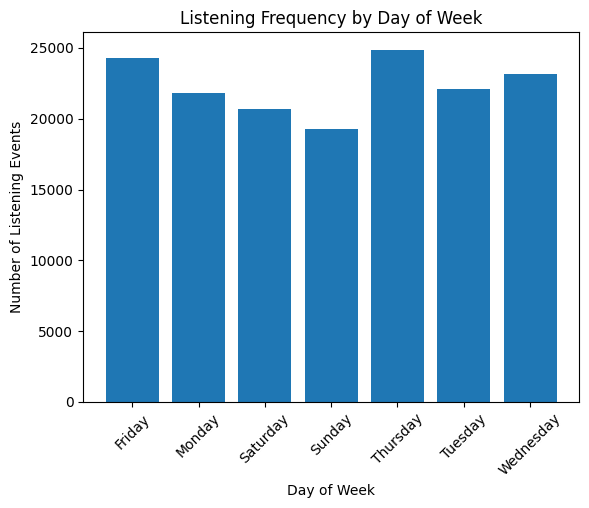

In [17]:
day_counts = df["day_of_week"].value_counts().sort_index()
plt.figure()
plt.bar(day_counts.index, day_counts.values)

plt.title("Listening Frequency by Day of Week")
plt.xlabel("Day of Week")
plt.ylabel("Number of Listening Events")

plt.xticks(rotation=45)
plt.show()

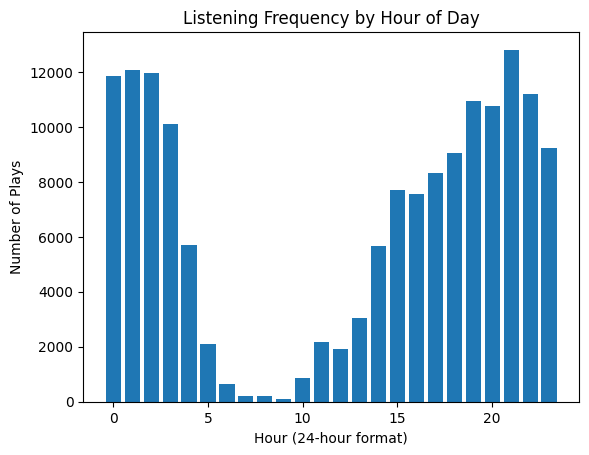

In [18]:
hour_counts = df["hour"].value_counts().sort_index()

plt.figure()
plt.bar(hour_counts.index, hour_counts.values)

plt.title("Listening Frequency by Hour of Day")
plt.xlabel("Hour (24-hour format)")
plt.ylabel("Number of Plays")

plt.show()

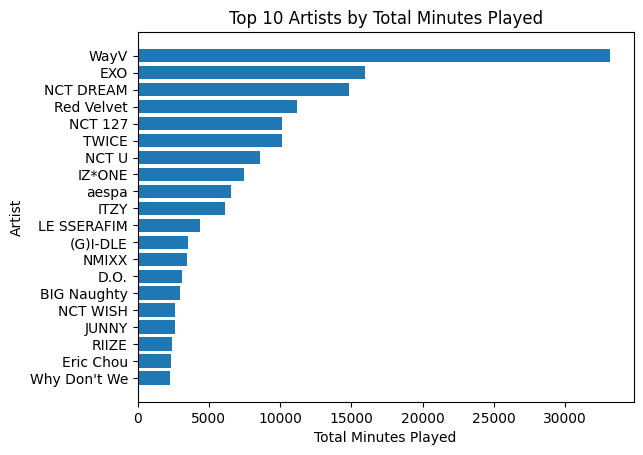

In [19]:
top_artists = (
    df.groupby("artist_name")["minutes_played"]
      .sum()
      .sort_values(ascending=False)
      .head(20)
)

plt.figure()
plt.barh(top_artists.index, top_artists.values)

plt.title("Top 10 Artists by Total Minutes Played")
plt.xlabel("Total Minutes Played")
plt.ylabel("Artist")

plt.gca().invert_yaxis()
plt.show()

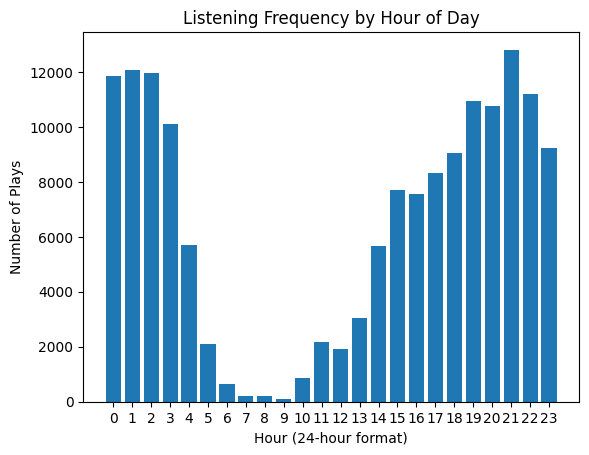

In [20]:
hour_counts = df["hour"].value_counts().sort_index()

plt.figure()
plt.bar(hour_counts.index, hour_counts.values)

plt.title("Listening Frequency by Hour of Day")
plt.xlabel("Hour (24-hour format)")
plt.ylabel("Number of Plays")

plt.xticks(range(0, 24))
plt.show()

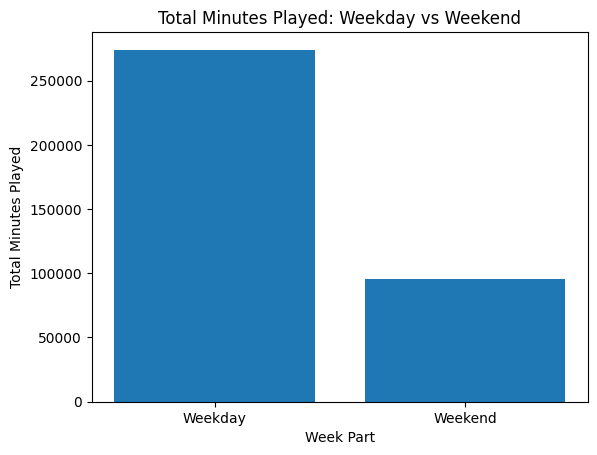

In [21]:
is_weekend = (df["day_of_week"] == 'Saturday') | (df["day_of_week"] == 'Sunday')
is_weekend.head()

df["week_part"] = is_weekend.map({True: "Weekend", False: "Weekday"})
df["week_part"].value_counts()

minutes_by_weekpart = df.groupby("week_part")["minutes_played"].sum()
minutes_by_weekpart

plt.figure()
plt.bar(minutes_by_weekpart.index, minutes_by_weekpart.values)

plt.title("Total Minutes Played: Weekday vs Weekend")
plt.xlabel("Week Part")
plt.ylabel("Total Minutes Played")

plt.show()

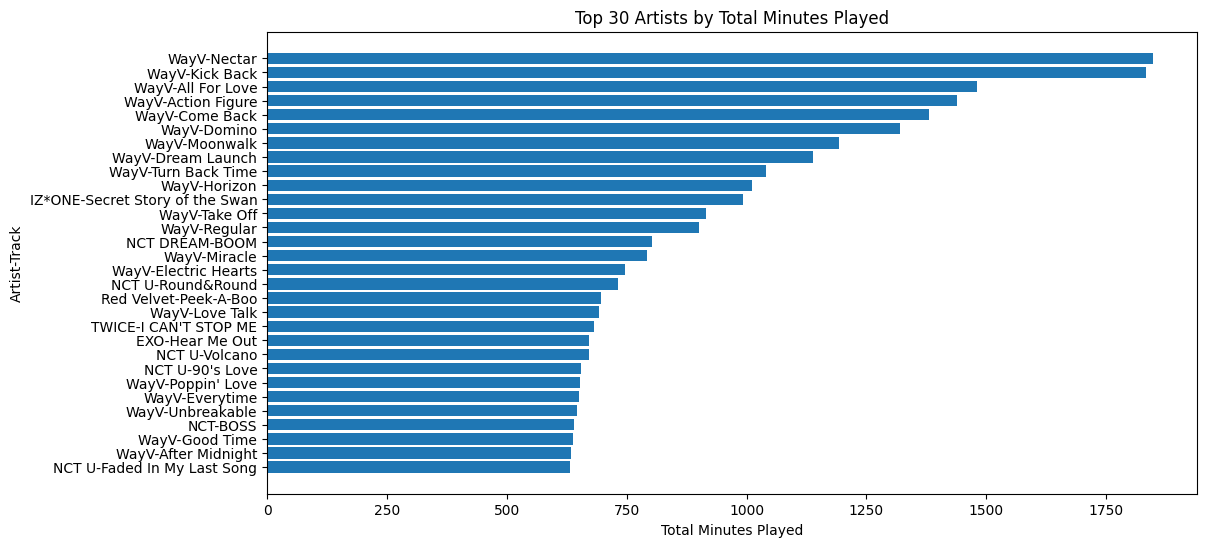

In [22]:
df["artists_track"] = df["artist_name"].astype(str) + "-" + df["track_name"].astype(str)

top_artists_track = (
    df.groupby("artists_track")["minutes_played"]
      .sum()
      .sort_values(ascending=False)
      .head(30)
)

plt.figure(figsize=(12, 6))
plt.barh(top_artists_track.index, top_artists_track.values)

plt.title("Top 30 Artists by Total Minutes Played")
plt.xlabel("Total Minutes Played")
plt.ylabel("Artist-Track")

plt.gca().invert_yaxis()
plt.show()

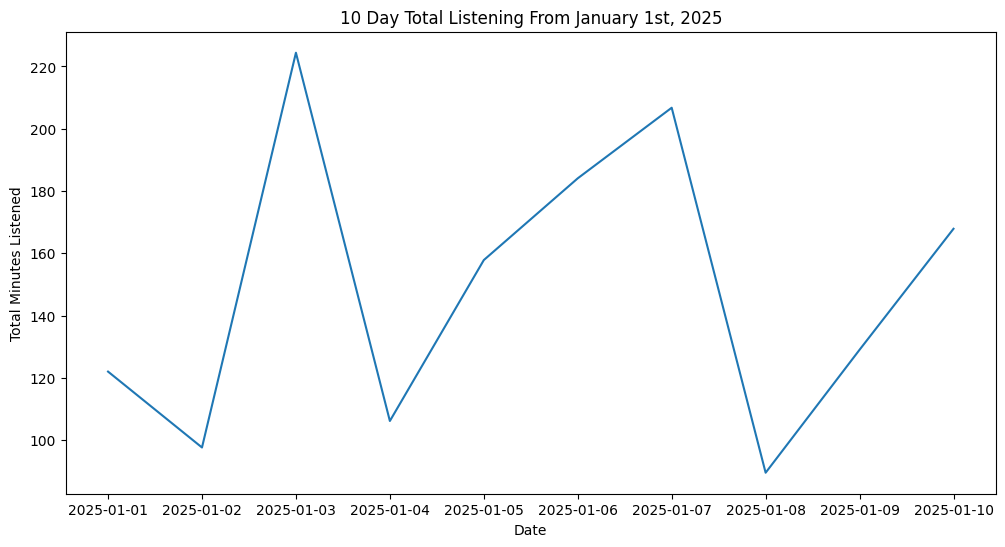

In [23]:
daily_listening = (
    df.groupby("date")["minutes_played"]
    .sum()
    .sort_index()
    .loc["2025-01-01":]
    .head(10)
)

plt.figure(figsize=(12, 6))
plt.plot(daily_listening.index, daily_listening.values)

plt.title("10 Day Total Listening From January 1st, 2025")
plt.xlabel("Date")
plt.ylabel("Total Minutes Listened")
plt.show()

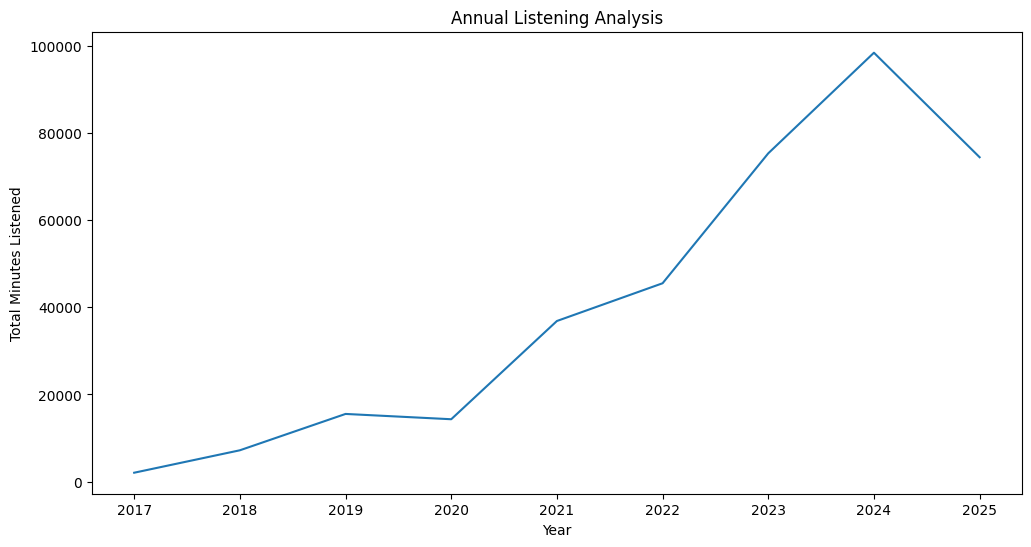

In [36]:
df["date"] = pd.to_datetime(df["date"])


yearly_listening = ( 
    df.groupby(df["date"].dt.year)["minutes_played"] 
    .sum() 
    .sort_index() 
    # .loc[2023:]  # Starts at the year 2023
)

plt.figure(figsize=(12, 6)) 
plt.plot(yearly_listening.index, yearly_listening.values) 
plt.title("Annual Listening Analysis") 
plt.xlabel("Year") 
plt.ylabel("Total Minutes Listened") 
# Ensure the x-axis only shows integer years
plt.xticks(yearly_listening.index)
plt.show()

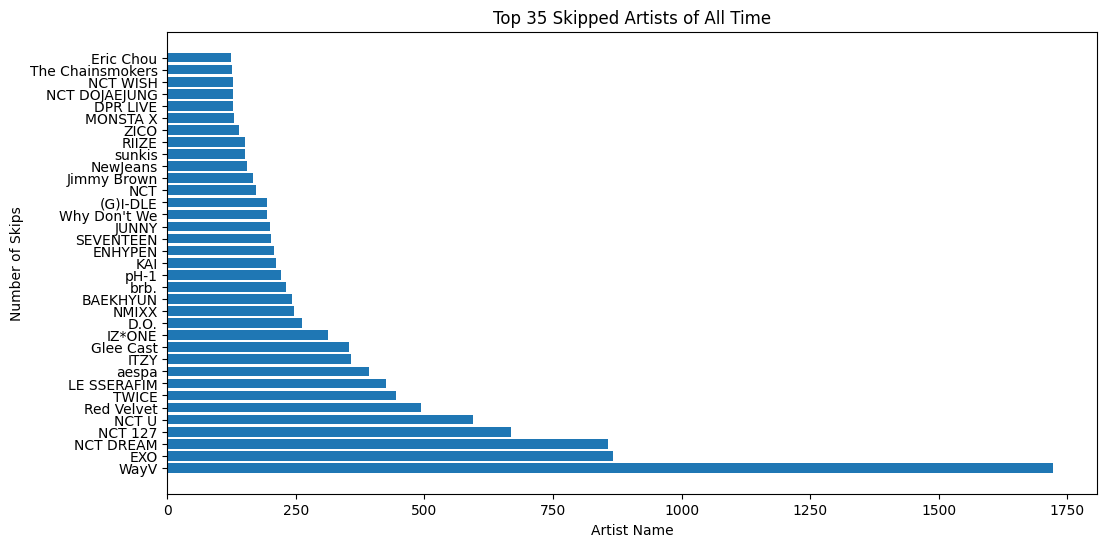

In [42]:
skipped_songs = df[df["minutes_played"]< 0.5]
skipped_songs.head()

skipped_artists = (
    skipped_songs.groupby("artist_name")["track_name"]
    .count()
    .sort_values(ascending=False)
    .head(35)
)

plt.figure(figsize=(12, 6)) 
plt.barh(skipped_artists.index, skipped_artists.values) 
plt.title("Top 35 Skipped Artists of All Time") 
plt.xlabel("Artist Name") 
plt.ylabel("Number of Skips") 
plt.show()